# Лабораторная работа №2. Просодика

Выполнила: Перминова Анастасия, группа M4221


Изучена разметка корпуса (паузы, их длительность), подготовлен набор «токен → пауза/отсутствие паузы → длина паузы», построен предиктор на основе правил: пауза ставится после знака препинания, а ее длительность равна медиане для этого знака. Дстигнуты целевые метрики (F1 ≥ 0,70, MAE < 0,120 с) на тесте. Данный подход ограничен тем, что около трети пауз в корпусе не связаны со знаками препинания (в основном короткие).

- `prepare_training_data.py` - нормализация меток, выравнивание слов с текстом, метки пауз, итоговая таблица;
- `pause_predictor.py` - класс `PausePredictor` и расчет метрик;
- `report_utils.py` - оформление графиков.

In [9]:
import csv
import os
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from praatio import textgrid

import prepare_training_data as prep
import report_utils as ru
from pause_predictor import (PausePredictor, load_data, predict_dataframe, calc_metrics,
                             test_pause_predictor, split_token, main_punct)

ru.set_style()

## 1. Данные

Корпус RUSLAN состоит из коротких реплик. К каждой реплике прилагается:
текст - в данной работе это нормализованный текст из первой лабораторной (21 759 реплик после фильтрации) и разметка `.TextGrid`, построенная выравнивателем Montreal Forced Aligner (MFA) (слой слов и слой фонем с  временными границами).

В словесном слое пустой интервал - пауза. Из таких интервалов получаем места и длительности пауз.

Разметка построена на сыром тексте и записана по правилам MFA (слова в нижнем регистре, без пунктуации, нестандартные символы заменены). Поэтому, чтобы связать паузы с нашим текстом и знаками препинания, слова из разметки и наш нормализованный текст нужно привести к общему виду. Это делается и в EDA, и в подготовке данных.

## 2. Разведочный анализ данных (EDA)

Нужно понять, как устроена разметка, какова средняя длительность паузы, слова, буквы и гласной, где в корпусе появляются паузы и насколько они логичны, какие классы пауз наблюдаются.

1. Прочитать все `.TextGrid` и получить слова и фонемы с длительностями.
2. Посчитать длительности слов, букв и гласных фонем.
3. Связать слова разметки с текстом, чтобы определить пунктуацию рядом с каждой паузой.
4. Описать паузы: места, длительности, классы.
5. Проверить, как длительность и место паузы зависят от знака препинания.

### 2.1 Чтение разметки

**Функция `read_textgrid(file_path)`:**
- открывает файл через `textgrid.openTextgrid(..., includeEmptyIntervals=True)`
- берет два слоя: `tiers[0]` - слова, `tiers[1]` - фонемы;
- для каждого интервала сохраняет начало, конец, длительность (`end - start`) и метку;
- возвращает два датафрейма: со словами и фонемами.

In [10]:
ALIGN_DIR = Path(prep.ALIGN_DIR)
textgrid_files = sorted(ALIGN_DIR.glob("*.TextGrid"))


def read_textgrid(file_path):

    tg = textgrid.openTextgrid(str(file_path), includeEmptyIntervals=True)
    words_tier = tg.tiers[0]
    phones_tier = tg.tiers[1]

    words = []
    for interval in words_tier.entries:
        start = interval.start
        end = interval.end
        label = interval.label
        words.append({"start": start, "end": end, "duration": end - start, "label": label})

    phones = []
    for interval in phones_tier.entries:
        start = interval.start
        end = interval.end
        label = interval.label
        phones.append({"start": start, "end": end, "duration": end - start, "label": label})

    return pd.DataFrame(words), pd.DataFrame(phones)


all_words = []
all_phones = []

for file_path in textgrid_files:
    audio_id = file_path.stem
    words_df, phones_df = read_textgrid(file_path)
    words_df["id"] = audio_id
    phones_df["id"] = audio_id
    all_words.append(words_df)
    all_phones.append(phones_df)

words_df = pd.concat(all_words, ignore_index=True)
phones_df = pd.concat(all_phones, ignore_index=True)

print("Обработано файлов:", len(all_words))
print("Интервалов в слое слов (слова и паузы):", len(words_df))
print("Количество фонем:", len(phones_df))

Обработано файлов: 22199
Интервалов в слое слов (слова и паузы): 317878
Количество фонем: 1488456


### 2.2 Длительности слов, букв и гласных

Считаем статистику длительностей и строим распределения.
Слово - любой непустой интервал в слое слов.  Буквы в наборе не размечены, поэтому длительность буквы считаем как длительность слова, деленная на количество букв в нем. Это приблизительный подсчет, так как в действительности, буквы имеют разную длительность.
Гласные - фонемы из набора `VOWELS` (13 гласных в IPA-записи MFA), берем их из фонетического слоя.

,количество,среднее,медиана,ст. откл.,мин,макс
слово,255447.0,410.6,410.0,224.2,10.0,5290.4
буква,255434.0,77.5,71.4,30.1,1.4,1160.0
гласная,603185.0,56.5,50.0,48.5,4.9,4310.0


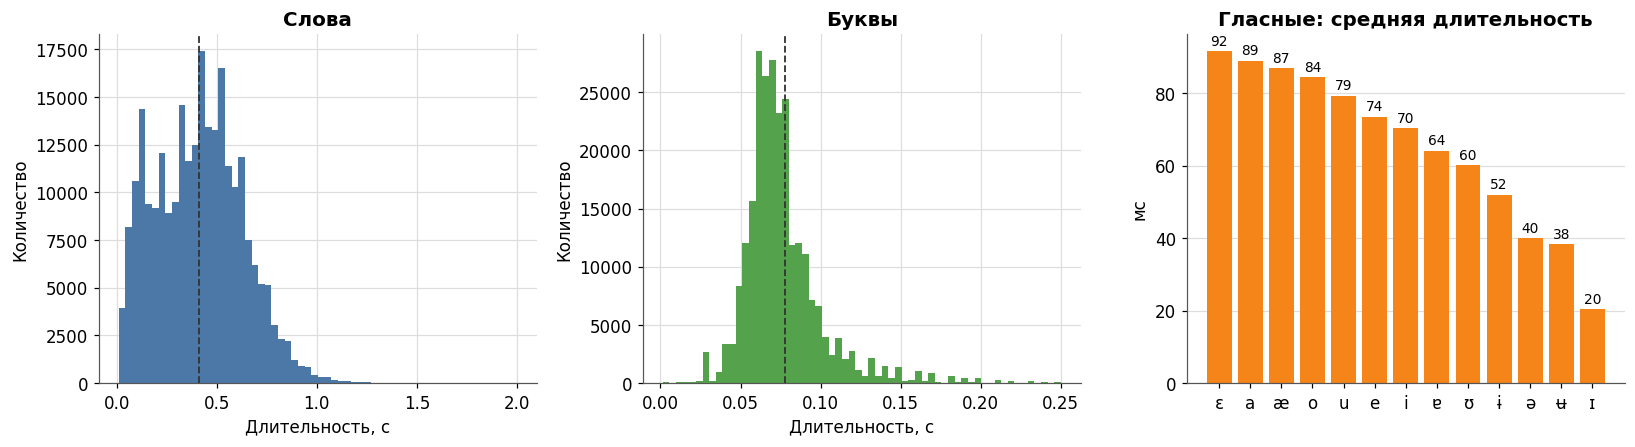

In [11]:
# слова без пустых интервалов (пауз)
real_words = words_df[words_df["label"].notna() & (words_df["label"] != "")].copy()

# количество букв и оценка длительности буквы
real_words["letters"] = (
    real_words["label"].astype(str).str.replace(r"[^А-Яа-яЁёA-Za-z]", "", regex=True).str.len()
)
words_with_letters = real_words[real_words["letters"] > 0].copy()
words_with_letters["estimated_letter_duration"] = words_with_letters["duration"] / words_with_letters["letters"]

# гласные фонемы, которые встречаются в TextGrid
VOWELS = {"a", "e", "i", "o", "u", "ɨ", "ɪ", "ə", "ɐ", "ʊ", "ɛ", "æ", "ʉ"}
vowels_df = phones_df[phones_df["label"].isin(VOWELS)].copy()

# сводная таблица, мс
series = {
    'слово': real_words.duration,
    'буква': words_with_letters.estimated_letter_duration,
    'гласная': vowels_df.duration,
}
summary = pd.DataFrame({name: (s * 1000).describe() for name, s in series.items()}).T
display(summary[['count', 'mean', '50%', 'std', 'min', 'max']].round(1)
        .rename(columns={'count': 'количество', 'mean': 'среднее', '50%': 'медиана', 'std': 'ст. откл.',
                         'min': 'мин', 'max': 'макс'}))

ru.plot_unit_durations(real_words, words_with_letters, vowels_df)

Слово в среднем длится 410 мс, буква ≈ 75–80 мс. Гласные довольно сильно различаются по длительности: ударные гласные длятся дольше (например, `æ`, `a`, `o`, `ɛ`) ≈ 85–90 мс, редуцированные же безударные оказываются короче (например, `ə`, `ɪ`, `ɐ`, `ʊ`) ≈ 20–60 мс.

### 2.3 Связь разметки с текстом: нормализация и выравнивание

Для каждого слова разметки находим его место в тексте. В разметке TextGrid отсутствует пунктуация, решения же о паузах связаны именно со знаками препинания. Чтобы знать, какой знак стоит рядом с паузой, нужно «наложить» слова разметки на текст.

**Нормализация меток** - функции `normalize_textgrid_label(label)` и `safe_normalize_label(label)`.
Метки приводятся к тем же правилам, что и текст в первой лабораторной, иначе мы не найдем слово в тексте. `normalize_textgrid_label` выполняет:
- Unicode-нормализацию NFC (одинаковая запись «й», «ё» и т. п.);
- замену технических символов (`* / @ + < > \ | ^ ~ _ # = { } % ° $ € ₽ № § © ®`) на пробел;
- приведение разных дефисов к обычному и разных кавычек к одному виду;
- нормализацию серий знаков (`!!!`, `?!`, `...` → `?!`, `…`), удаление случайных точек между словами и лишних пробелов.

Пустая метка (пауза) не меняется. `safe_normalize_label` - страховка: пустую метку она всегда возвращает как `''`, а если нормализация избавилась от слова целиком, возвращает исходную метку. Так настоящее слово не перепутается с паузой.

**Выравнивание** - функция `align_text_and_textgrid(tokens, text)`.
Она получает слова одной реплики из разметки и ее текст и находит каждое слово в тексте. Знаки между двумя словами приклеиваются к предыдущему слову, получается колонка `label_raw` (например, `чувством,`). Паузы получают метку `<SIL>`. Функция также проверяет, что между соседними словами в тексте есть только пунктуация: иначе может получиться так, что в тексте будет слово, которого нет в разметке, и дальнейшее сопоставление сдвинется. В этом случае (или если слово не найдено) функция записывает в `label_raw` значение `NaN`, и реплика исключается.

In [12]:
metadata = pd.read_csv(prep.RUSLAN_META, sep='|', names=['id', 'raw_text', 'normalized_text'], quoting=csv.QUOTE_NONE)

# нормализуем метки TextGrid (каждую уникальную метку один раз)
norm_words = words_df.copy()
label_map = {label: prep.safe_normalize_label(label) for label in norm_words.label.unique()}
norm_words['label'] = norm_words['label'].map(label_map)
groups = {audio_id: g for audio_id, g in norm_words.groupby('id', sort=False)}

# выравниваем слова каждой реплики с ее текстом
aligned = []
for audio_id, text in metadata[['id', 'normalized_text']].values:
    tokens = groups.get(audio_id)
    if tokens is None:                                
        continue
    result = prep.align_text_and_textgrid(tokens, unicodedata.normalize('NFC', text))

    # реплики, которые не удалось выровнять, пропускаем
    if not result['label_raw'].isna().any():            
        aligned.append(result)

aligned_words_df = pd.concat(aligned, ignore_index=True)
print(f'Реплик в метаданных: {len(metadata)}, выровнено: {len(aligned)}')

Реплик в метаданных: 21759, выровнено: 21756


**Пример:**

In [13]:
example = pd.DataFrame({'label': ['с', 'тревожным', 'чувством', '', 'берусь', ''],
                    'duration': [0.11, 0.58, 0.62, 0.19, 0.39, 0.03],
                    'id': 'example'})

example_aligned = prep.align_text_and_textgrid(example, 'С тревожным чувством, берусь.')
example_aligned

,label,duration,id,label_raw
0,с,0.11,example,С
1,тревожным,0.58,example,тревожным
2,чувством,0.62,example,"чувством,"
3,,0.19,example,<SIL>
4,берусь,0.39,example,берусь.
5,,0.03,example,<SIL>


Запятая после «чувством» и точка в конце приклеились к своим словам, а паузы обозначились как `<SIL>`.

### 2.4 Паузы: положения и длительности

Для каждой паузы находились соседние слова, сохранялась ее длительность. Таблица включает все паузы по корпусу: по ней видно, между какими словами и после каких знаков они стоят.

Цикл идет по текстам и по каждому пустому интервалу ищет ближайшее непустое слово слева (`previous_raw`, вместе с пунктуацией) и справа (`next_raw`). Если справа слов нет, это финальная пауза (`is_final_pause`), то есть тишина в конце записи. Остальные паузы - паузы между словами.

In [14]:
pause_positions = []

for audio_id, group in aligned_words_df.groupby("id"):
    group = group.reset_index(drop=True)

    for i in range(len(group)):
        if group.loc[i, "label"] != "":
            continue

        # предыдущее непустое слово
        j = i - 1
        previous_raw = ""

        while j >= 0:
            if group.loc[j, "label"] != "":
                previous_raw = group.loc[j, "label_raw"]
                break
            j -= 1

        # следующее непустое слово
        j = i + 1
        next_raw = ""

        while j < len(group):
            if group.loc[j, "label"] != "":
                next_raw = group.loc[j, "label_raw"]
                break
            j += 1

        pause_positions.append({
            "id": audio_id,
            "previous_raw": previous_raw,
            "next_raw": next_raw,
            "pause_duration": group.loc[i, "duration"],
            "is_final_pause": next_raw == ""
        })

pause_positions_df = pd.DataFrame(pause_positions)

internal_pauses = pause_positions_df[~pause_positions_df["is_final_pause"]]
final_pauses = pause_positions_df[pause_positions_df["is_final_pause"]]

print(f'Всего пауз: {len(pause_positions_df)}, между словами: {len(internal_pauses)}, финальных: {len(final_pauses)}')

pd.DataFrame({
    'между словами': internal_pauses['pause_duration'].describe(),
    'финальные': final_pauses['pause_duration'].describe(),
}).round(3)

Всего пауз: 60427, между словами: 48369, финальных: 12058


,между словами,финальные
count,48369.000,12058.000
mean,0.158,0.042
std,0.150,0.089
min,0.030,0.025
25%,0.040,0.028
50%,0.100,0.030
75%,0.230,0.034
max,1.670,7.095


Финальные паузы - это границы записи. Их медиана ≈ 30 мс, но встречаются и длиной до нескольких секунд. Они не отражают естественное распределение пауз, поэтому при обучении и оценке не используются. Паузы между словами в среднем ≈ 160 мс.

**Классы пауз по длительности.** Разобьем паузы между словами на классы и посмотрим на распределение.

,count,percent
pause_duration,,
< 50 мс,15683,32.4
50–100 мс,8379,17.3
100–200 мс,10029,20.7
200–400 мс,9903,20.5
400–700 мс,4190,8.7
0.7–1 с,177,0.4
1–2 с,8,0.0
> 2 с,0,0.0


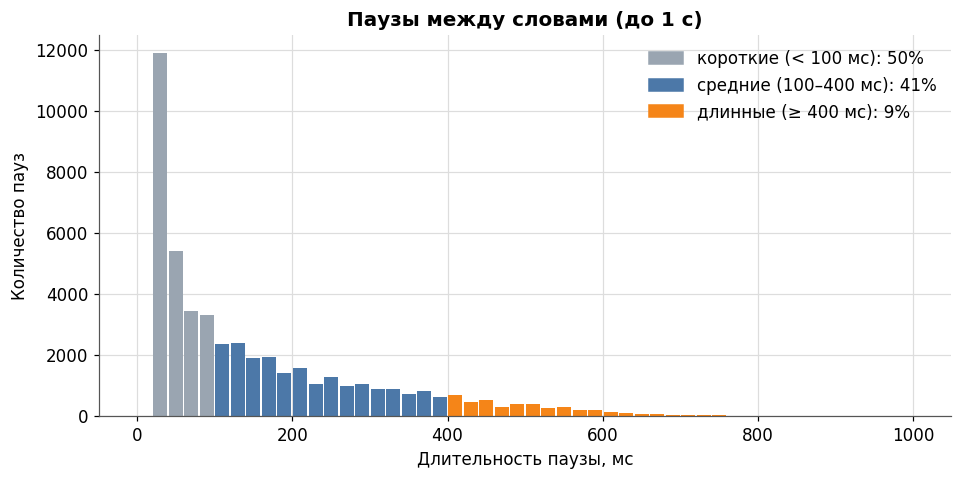

In [15]:
bins = [0, 0.05, 0.1, 0.2, 0.4, 0.7, 1, 2, float("inf")]
labels = ["< 50 мс", "50–100 мс", "100–200 мс", "200–400 мс", "400–700 мс", "0.7–1 с", "1–2 с", "> 2 с"]

pause_classes = pd.cut(internal_pauses["pause_duration"], bins=bins, labels=labels, right=False)
pause_stats = pause_classes.value_counts(sort=False).rename("count").to_frame()
pause_stats["percent"] = pause_stats["count"] / len(internal_pauses) * 100

display(pause_stats.round(1))
ru.plot_pause_hist(internal_pauses["pause_duration"])

Распределение несимметрично: коротких пауз больше всего, затем идет плавный спад. Условно выделяются три класса:
- **короткие (< 100 мс)** - около половины всех пауз (наверное, микропаузы на границах слов);
- **средние (100–400 мс)** - около 40%;
- **длинные (> 400 мс)** - около 10%.

### 2.5 Паузы и знаки препинания

Места и длительность пауз в первую очередь определяются знаками препинания.

Функция `get_punctuation(row)` определяет тип паузы по строкам таблицы пауз. Сначала проверяется `is_final_pause` (тогда это `final`), иначе анализируется конец `previous_raw` - слова перед паузой, вместе с пунктуацией. Важно проверять в правильном порядке: многоточие нужно проверить раньше точки.

,пауз,"среднее, с","медиана, с","ст. откл., с","мин, с","макс, с"
punctuation,,,,,,
нет знака,15765,0.096,0.04,0.114,0.030,1.670
точка,12224,0.214,0.18,0.156,0.030,1.230
конец реплики,12058,0.042,0.03,0.089,0.025,7.095
запятая,10232,0.150,0.09,0.150,0.030,1.040
тире,5805,0.189,0.14,0.156,0.030,1.260
многоточие,2257,0.194,0.16,0.149,0.030,1.070
?,1155,0.211,0.18,0.153,0.030,0.860
!,930,0.206,0.16,0.157,0.030,0.810
точка с запятой,1,0.410,0.41,NaN,0.410,0.410


Доля пауз между словами, где после слова нет знака препинания: 0.326


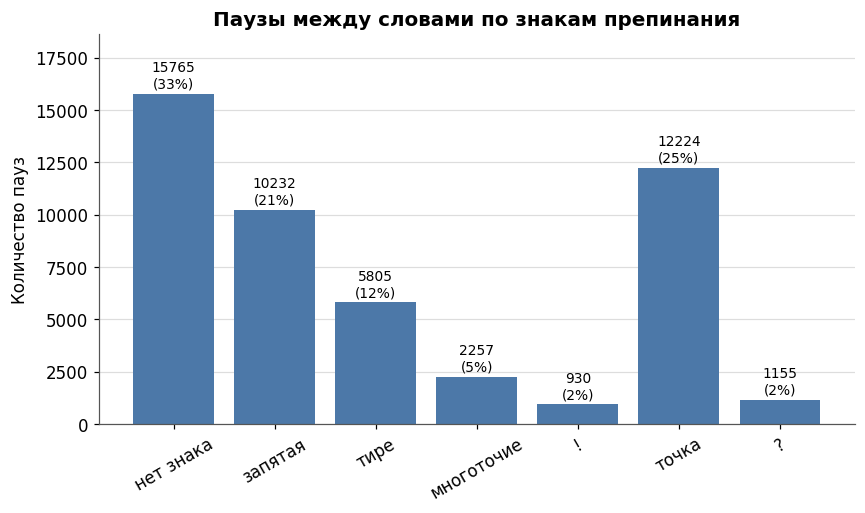

In [16]:
def get_punctuation(row):
    if row["is_final_pause"]:
        return "final"

    text = str(row["previous_raw"]).strip()

    if text.endswith("...") or text.endswith("…"):
        return "ellipsis"
    if text.endswith("?"):
        return "question"
    if text.endswith("!"):
        return "exclamation"
    if text.endswith(","):
        return "comma"
    if text.endswith(";"):
        return "semicolon"
    if text.endswith(":"):
        return "colon"
    if text.endswith(("—", "–", "-")):
        return "dash"
    if text.endswith("."):
        return "period"

    return "none"


pause_positions_df["punctuation"] = pause_positions_df.apply(get_punctuation, axis=1).map(ru.PUNCT_RU)

stats = pause_positions_df.groupby("punctuation")["pause_duration"].agg(["count", "mean", "median", "std", "min", "max"])
display(stats.sort_values("count", ascending=False).round(3)
        .rename(columns={"count": "пауз", "mean": "среднее, с", "median": "медиана, с", "std": "ст. откл., с",
                         "min": "мин, с", "max": "макс, с"}))

inner = pause_positions_df[~pause_positions_df["is_final_pause"]]
print('Доля пауз между словами, где после слова нет знака препинания:', round((inner.punctuation == 'нет знака').mean(), 3))

ru.plot_punctuation(pause_positions_df)

Длительность пауз заметно зависит от знака препинания. Самые короткие паузы наблюдаются в конце реплики (медиана 0,03 с) и при отсутствии знака (0,04 с), тогда как после точки, вопросительного и восклицательного знаков медиана составляет около 0,16–0,18 с. Запятые и тире характеризуются промежуточными значениями. Таким образом, знак препинания является информативным признаком для предсказания как наличия, так и длительности паузы.

### 2.6 Выводы EDA:

Минимальная пауза между словами в разметке ≈ 30 мс, около трети пауз короче 50 мс. Такие паузы, скорее всего, даже не слышно (вероятно, это границы слов).
Паузы без знаков препинания составляют ≈ 1/3 пауз между словами. Они ограничивают работу любого предиктора, основанного на пунктуации.
Финальные паузы - признак границы файла, в обучении и оценке не используются.
Длинные паузы (> 1 с) единичны, среди пауз между словами максимум ≈ 1,7 с, статистику это не портит.
Почти все реплики удалось выровнять с текстом, то есть нормализованный текст и разметка хорошо согласуются.

## 3. Подготовка данных

Необходимо было превратить результаты EDA в набор данных для обучения предиктора. Для каждого слова реплики записано, стоит ли после него пауза и какой она длины. Слова идут в исходном порядке, пунктуация сохраняется, потому что на входе предиктора будет только текст. Это реализуется в скрипте скрипт `prepare_training_data.py`; он повторяет шаги EDA, но оформляет их как функции, добавляет проверки и сохраняет результат в `data/RUSLAN_pause_metadata.csv`.

1. **`read_text_grids(ruslan, align_root)`** читает слой слов из `.TextGrid` для всех реплик метаданных и возвращает таблицу слов (метка, длительность, id). Если файла нет, реплика пропускается, а причина первой ошибки печатается.
2. **`safe_normalize_label` / `normalize_textgrid_label`** нормализуют метки разметки, чтобы слова нашлись в тексте.
3. **`align_text_and_textgrid(tokens, text)`** сопоставляет слова разметки с текстом и формирует `label_raw`. Реплики, которые не удалось выровнять, отбрасываются, а их `id` сохраняются в `data/RUSLAN_pause_failed_ids.txt`.
4. **`add_pause_labels(align)`** создает целевые метки: для каждого слова ищет сразу следующий за ним пустой интервал и записывает `is_pause_after = 1` и `pause_duration` (его длину). Последнее слово реплики получает `is_last_word = 1`. Тишина в начале реплики ни к какому слову не относится и отбрасывается.
5. **`main()`** связывает все вместе: читает метаданные, выравнивает все реплики, добавляет метки пауз, удаляет строки самих пауз (вся информация о них теперь в словах), размечает `train`/`test` и сохраняет файл.

**Разбиение на `train` и `test`.** Реплики, номер которых делится на 5, попадают в `test` (≈ 20%), остальные - в `train`.

| Метка | Значение |
|---|---|
| `id` | идентификатор реплики |
| `label` | нормализованное слово из разметки |
| `label_raw` | слово из текста вместе с пунктуацией после него |
| `duration` | длительность слова, с |
| `is_last_word` | 1, если это последнее слово реплики |
| `is_pause_after` | 1, если после слова есть пауза |
| `pause_duration` | длительность этой паузы, с (0, если паузы нет) |
| `set` | `train` или `test` |

Функция `add_pause_labels` на том же маленьком примере (из 2.3): пауза после «чувством» (0,19 с) записалась этому слову, а у слова «берусь» `is_last_word = 1`, и его пауза - финальная.

In [17]:
prep.add_pause_labels(example_aligned)

,label,duration,id,label_raw,is_last_word,is_pause_after,pause_duration
0,с,0.11,example,С,False,False,0.00
1,тревожным,0.58,example,тревожным,False,False,0.00
2,чувством,0.62,example,"чувством,",False,True,0.19
3,,0.19,example,<SIL>,False,False,0.00
4,берусь,0.39,example,берусь.,True,True,0.03
5,,0.03,example,<SIL>,False,False,0.00


Теперь запускаем скрипт целиком и загружаем итоговую таблицу функцией `load_data()` из `pause_predictor.py`: она читает CSV с разделителем `|` и без обработки кавычек.

In [18]:
if not os.path.exists(prep.RESULT_PATH):
    prep.main()                     

pause_df = load_data()

size = pause_df.groupby('id')['id'].transform('size')
example_id = pause_df[(pause_df.set == 'test') & pause_df.label_raw.str.endswith(',')
                      & (pause_df.is_pause_after == 1) & (size <= 12)].id.iloc[0]
pause_df[pause_df.id == example_id].drop(columns=['id'])

,label,duration,label_raw,is_last_word,is_pause_after,pause_duration,set
64,я,0.15,Я,0,0,0.000000,test
65,дважды,0.41,дважды,0,0,0.000000,test
66,был,0.19,был,0,0,0.000000,test
67,женат,0.52,"женат,",0,1,0.140000,test
68,и,0.14,и,0,0,0.000000,test
69,оба,0.25,оба,0,0,0.000000,test
70,раза,0.26,раза,0,0,0.000000,test
71,счастливо,0.50,счастливо.,1,1,0.028662,test


В примере виден формат таблицы: `label_raw` хранит слово вместе с пунктуацией, у слова с запятой `is_pause_after = 1`, а `pause_duration` - длина паузы в секундах; у последнего слова `is_last_word = 1`.

**Сколько реплик потеряно при подготовке:**

In [19]:
failed_ids = open(prep.FAILED_IDS_PATH, encoding='utf-8').read().split()
n_done = pause_df.id.nunique()

print(f'Реплик в метаданных: {len(metadata)}')
print(f'Нет .TextGrid: {len(metadata) - n_done - len(failed_ids)}')
print(f'Не удалось выровнять с текстом: {len(failed_ids)}')
print(f'В итоговой таблице: {n_done}')

pause_df.groupby('set').agg(Предложений=('id', 'nunique'), Токенов=('id', 'size'))

Реплик в метаданных: 21759
Нет .TextGrid: 1
Не удалось выровнять с текстом: 2
В итоговой таблице: 21756


,Предложений,Токенов
set,,
test,4366,49890
train,17390,199458


Потери небольшие (< 0,02%): разметка хорошо согласуется с нормализованным текстом, и дополнительная очистка здесь не нужна. Разбиение на `train` и `test` - около 80% / 20%.

## 4. Предиктор пауз

EDA показал, что длительность паузы сильно зависит от знака препинания, а большинство важных пауз стоит именно после пунктуации.

**Место паузы.** Если после слова стоит знак препинания, после него ставится пауза. После последнего токена пауза не предсказывается (это стык аудиофайлов).
**Длительность.** Для каждого знака по `train` считаем медиану длительности пауз после него.

**Функции и класс из `pause_predictor.py`:**
- **`split_token(token)`** делит токен на слово и пунктуацию в его конце с помощью регулярного выражения: `'чувством,' → ('чувством', ',')`. Пробелы в пунктуации удаляются.
- **`main_punct(token)`** возвращает первый знак из набора `, . ! ? : — – …` в конце токена или `''`, если знака нет.
- **`PausePredictor.fit(df)`** обучение: берет из таблицы только `train`, исключает последние слова, оставляет только токены с паузой и знаком и считает медиану `pause_duration` для каждого знака (`median_duration`). Для знака, которого не было в `train`, есть запасное значение (`default_duration`).
- **`PausePredictor.predict(tokens)`** получает токены реплики и возвращает два массива: `is_pause` (0/1) и `pause_duration`. Пауза ставится, если у токена есть знак из набора и он не последний; длительность - медиана для этого знака.
- **`PausePredictor.predict_durations(tokens)`**: возвращает токены, в которые после каждого токена с паузой вставлена метка `<SIL>`, и длительности. У обычных токенов длительность `-1`, а у `<SIL>` - предсказанная длительность паузы.
- **`predict_dataframe(predictor, df)`** применяет `predict` к каждой реплике таблицы и добавляет колонки `is_pause_hat` и `pause_duration_hat`.
- **`calc_metrics(df)`** считает Precision, Recall и F1 по `is_pause_after` и MAE длительности. MAE считается только на верных срабатываниях: пауза есть и в разметке, и в предсказании.
- **`test_pause_predictor()`** весь цикл: загрузка таблицы, обучение на `train`, предсказание и метрики на `train` и `test` без последних слов реплик.

In [20]:
[(t, split_token(t), main_punct(t)) for t in ['чувством,', 'перо.', 'словом', 'да—']]

[('чувством,', ('чувством', ','), ','),
 ('перо.', ('перо', '.'), '.'),
 ('словом', ('словом', ''), ''),
 ('да—', ('да', '—'), '—')]

In [21]:
predictor = PausePredictor().fit(pause_df)        

pd.Series(predictor.median_duration, name='медиана, с').round(3).to_frame()

,"медиана, с"
!,0.16
",",0.09
.,0.18
?,0.17
–,0.13
…,0.16


Пример на реплике из `test`: слева токены и их разметка, затем предсказание `predict` и формат `predict_durations`. Предсказание зависит только от знака, поэтому для одинаковых знаков длительность одинакова. Ошибки возникают там, где диктор не сделал паузу после знака или сделал ее без знака.

In [22]:
sentence = pause_df[pause_df.id == example_id]
is_pause, durations = predictor.predict(sentence.label_raw.values)

display(pd.DataFrame({'токен': sentence.label_raw.values,
                      'пауза в разметке, с': sentence.pause_duration.values,
                      'предсказано, с': durations.round(3)}))

tokens_w_pauses, durations_w_pauses = predictor.predict_durations(sentence.label_raw.values)
pd.DataFrame({'элемент': tokens_w_pauses, 'длительность, с': durations_w_pauses.round(3)})

,токен,"пауза в разметке, с","предсказано, с"
0,Я,0.000000,0.00
1,дважды,0.000000,0.00
2,был,0.000000,0.00
3,"женат,",0.140000,0.09
4,и,0.000000,0.00
5,оба,0.000000,0.00
6,раза,0.000000,0.00
7,счастливо.,0.028662,0.00


,элемент,"длительность, с"
0,Я,-1.00
1,дважды,-1.00
2,был,-1.00
3,"женат,",-1.00
4,<SIL>,0.09
5,и,-1.00
6,оба,-1.00
7,раза,-1.00
8,счастливо.,-1.00


### 4.2 Замеры на train и test

При подсчете метрик последние слова предложений исключены; F1 - по `is_pause_after`; MAE - только по верным срабатываниям. Целевые значения: F1 ≥ 0,70, MAE < 0,120 с.

In [23]:
test_pause_predictor()

100%|███████████████████████████████████████████████████████████████████████████| 21756/21756 [01:32<00:00, 235.58it/s]



Calculate metrics, training fold; Exclude last tokens in every sentence!
PRC: 0.741, REC: 0.698, F1: 0.719; MAE: 0.118

Calculate metrics, testing fold; Exclude last tokens in every sentence!
PRC: 0.732, REC: 0.696, F1: 0.713; MAE: 0.117


**Результат.** Оба порога выполнены на `test`: F1 ≈ 0,71, MAE ≈ 0,117 с. Результаты на `train` и `test` почти совпадают.

**Где теряется качество.** Precision ≈ 0,73 и Recall ≈ 0,70. Чтобы понять причины, посмотрим, как часто после каждого знака действительно есть пауза.

In [25]:
tokens = pause_df.rename(columns={'label_raw': 'previous_raw'})
tokens['is_final_pause'] = tokens['is_last_word'] == 1
tokens['punctuation'] = tokens.apply(get_punctuation, axis=1).map(ru.PUNCT_RU)

inner = tokens[tokens['is_last_word'] == 0]
rate = inner.groupby('punctuation')['is_pause_after'].agg(['size', 'mean'])
rate['mean'] = (rate['mean'] * 100).round(1)
rate.reindex([p for p in ru.PUNCT_ORDER if p in rate.index]).rename(
    columns={'size': 'токенов', 'mean': 'доля токенов с паузой, %'})

,токенов,"доля токенов с паузой, %"
punctuation,,
нет знака,183032,8.1
запятая,18624,54.9
тире,8595,67.5
многоточие,2397,94.2
!,981,94.8
точка,12680,96.4
?,1282,90.1


Предиктор не предсказывает токены без знака препинания, а на них приходится около трети всех пауз. Это главный источник потери полноты. При этом наличие знака не гарантирует паузу: после запятой пауза возникает в 54,9% случаев, после тире - в 67,5%, тогда как после точки, многоточия, ! и ? - более чем в 90% случаев. Поэтому часть предсказанных по знаку пауз оказывается ложной. MAE ≈ 0,117 с может объясняться тем, что даже внутри одной категории знака длительность пауз сильно варьируется: стандартное отклонение составляет порядка 150 мс. Кроме того, для разных знаков характерны заметно разные типичные длительности: медиана составляет около 0,09 с для запятой, 0,14 с для тире, 0,16–0,18 с для точки, многоточия, ! и ?. Следовательно, одного только типа знака достаточно для грубой оценки паузы, но недостаточно для точного предсказания ее длительности.

### 4.3 Нужна ли дополнительная фильтрация данных

Из EDA следует, что часть разметки сомнительна. Обязательная фильтрация уже сделана: исключены финальные паузы (`is_last_word`) и реплики, не выровнявшиеся с текстом. Проверяемм последнюю спорную часть - короткие паузы: считаем паузы короче 50 мс отсутствующими и при обучении, и при оценке и сравниваем со строкой `testing fold` из предыдущего раздела.

In [26]:
clean = pause_df.copy()
short = (clean.is_pause_after == 1) & (clean.pause_duration < 0.05)
clean.loc[short, ['is_pause_after', 'pause_duration']] = 0       # паузы < 50 мс = паузы нет

clean_pred = predict_dataframe(PausePredictor().fit(clean), clean)
calc_metrics(clean_pred[(clean_pred.set == 'test') & (clean_pred.is_last_word == 0)])

100%|███████████████████████████████████████████████████████████████████████████| 21756/21756 [00:54<00:00, 401.55it/s]

PRC: 0.584, REC: 0.786, F1: 0.670; MAE: 0.117


1. Обязательно убираем финальные паузы и реплики без выравнивания. Это уже входит в подготовку данных и в оценку.
2. Порог по длительности не нужен. При пороге 50 мс F1 на `test` падает примерно с 0,71 до 0,67. Слова со знаком по-прежнему получают паузу, а  «короткая» пауза после знака уже считается ее отсутствием, поэтому увеличивается число ложных срабатываний. MAE при этом практически не меняется (≈ 0,117 с).